In [3]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, classification_report

print("AMR Machine Learning Demonstration")


AMR Machine Learning Demonstration


In [4]:
rng = np.random.default_rng(42)

n = 600

organisms = rng.choice(
    [
        "E. coli",
        "Klebsiella pneumoniae",
        "Pseudomonas aeruginosa",
        "Acinetobacter baumannii"
    ],
    n,
    p=[0.40, 0.25, 0.20, 0.15]
)

specimens = rng.choice(
    ["Urine", "Blood", "Wound/Swab", "Respiratory"],
    n,
    p=[0.45, 0.20, 0.20, 0.15]
)

wards = rng.choice(
    ["Medical", "Surgical", "ICU", "Pediatrics"],
    n,
    p=[0.35, 0.30, 0.20, 0.15]
)

age_group = rng.choice(
    ["Child", "Adult", "Older adult"],
    n,
    p=[0.18, 0.67, 0.15]
)

base = np.where(
    np.isin(
        organisms,
        ["Klebsiella pneumoniae", "Acinetobacter baumannii"]
    ),
    0.62,
    0.32
)

base += np.where(wards == "ICU", 0.12, 0)
base += np.where(specimens == "Blood", 0.04, 0)

prob_resistant = np.clip(base, 0.05, 0.90)

resistant = rng.binomial(1, prob_resistant)

df = pd.DataFrame({
    "organism": organisms,
    "specimen": specimens,
    "ward": wards,
    "age_group": age_group,
    "resistant": resistant
})

df.head()

,organism,specimen,ward,age_group,resistant
0,Pseudomonas aeruginosa,Blood,Surgical,Adult,0
1,Klebsiella pneumoniae,Wound/Swab,Surgical,Adult,0
2,Acinetobacter baumannii,Respiratory,ICU,Child,0
3,Pseudomonas aeruginosa,Wound/Swab,ICU,Adult,1
4,E. coli,Respiratory,Medical,Adult,1


In [5]:
resistance_by_organism = (
    df.groupby("organism")["resistant"]
    .mean()
    .sort_values(ascending=False) * 100
)

print("Resistance percentage by organism:")
print(resistance_by_organism)

Resistance percentage by organism:
organism
Klebsiella pneumoniae      67.741935
Acinetobacter baumannii    53.750000
Pseudomonas aeruginosa     33.858268
E. coli                    31.512605
Name: resistant, dtype: float64


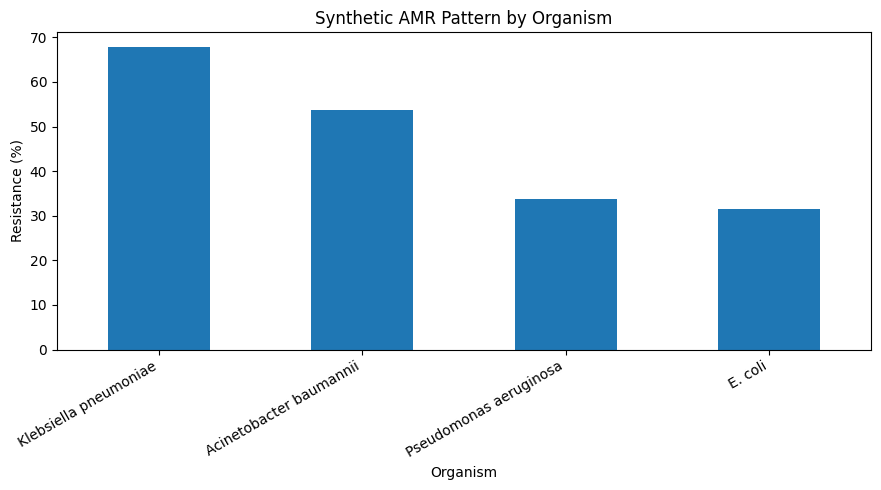

In [6]:
resistance_by_organism.plot(
    kind="bar",
    figsize=(9, 5)
)

plt.ylabel("Resistance (%)")
plt.xlabel("Organism")
plt.title("Synthetic AMR Pattern by Organism")
plt.xticks(rotation=30, ha="right")
plt.tight_layout()
plt.show()

In [7]:
X = df[
    ["organism", "specimen", "ward", "age_group"]
]

y = df["resistant"]

categorical_features = X.columns.tolist()

preprocessor = ColumnTransformer(
    [
        (
            "categorical",
            OneHotEncoder(handle_unknown="ignore"),
            categorical_features
        )
    ]
)

model = Pipeline(
    [
        ("preprocessor", preprocessor),
        (
            "classifier",
            RandomForestClassifier(
                n_estimators=150,
                random_state=42,
                class_weight="balanced"
            )
        )
    ]
)

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42,
    stratify=y
)

model.fit(X_train, y_train)

predictions = model.predict(X_test)

print("Accuracy:", round(
    accuracy_score(y_test, predictions), 3
))

print("\nClassification report:")
print(classification_report(y_test, predictions))

Accuracy: 0.525

Classification report:
              precision    recall  f1-score   support

           0       0.57      0.63      0.60        67
           1       0.46      0.40      0.42        53

    accuracy                           0.53       120
   macro avg       0.51      0.51      0.51       120
weighted avg       0.52      0.53      0.52       120



In [11]:
## Interpretation

This demonstration shows how routinely generated microbiology variables can be organized and analyzed using Python and machine learning.

The synthetic model is intended only to demonstrate a technical workflow. It is not a clinical prediction model and should not be used for patient-care decisions.

In a real hospital setting, future models could incorporate antimicrobial susceptibility profiles, specimen type, ward, temporal trends, previous antibiotic exposure, and other clinically relevant variables.

The long-term objective is to explore how microbiology data can support antimicrobial resistance surveillance, antimicrobial stewardship, and clinical decision support.


In [ ]:
## Ethical Considerations

This project uses synthetic data and contains no patient-identifiable information.

Any future analysis using real clinical data would require appropriate institutional authorization, data governance, ethical review where applicable, and rigorous clinical validation.